# V-BReE Confidence Score Assessments

## 1. Data load and workspace prepration

In [56]:
# %pip install scikit-learn
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
import scipy.stats as stats


## 1.1. Load sample and primary results

In [57]:
##BASELINE DATA
sample = pd.read_csv("../data/mmlu_pro_12_cat_250_sample_20260306.csv")

data = pd.read_csv('../data/full_sample_results/v-bree_mmlupro_test_0_3000_20260306_final.csv')

merged = pd.merge(data, sample[["question_id", "answer"]], left_on = "id", right_on = "question_id", how = "left")

# chosen_responses = merged[merged["chosen_response"] == True]

# display(chosen_responses.head(5))



##EVT DATA
# data = pd.read_csv("../data/variance_threshold_testing_data/vbree_mmlupro_var_thresh_testing_20260401.csv")

# merged = pd.merge(data, sample[["question_id", "answer"]], left_on = "id", right_on = "question_id", how = "left")



## Check Confidence Score Distribution

Text(0.5, 1.0, 'Log Transformed Confidence Score Distribution')

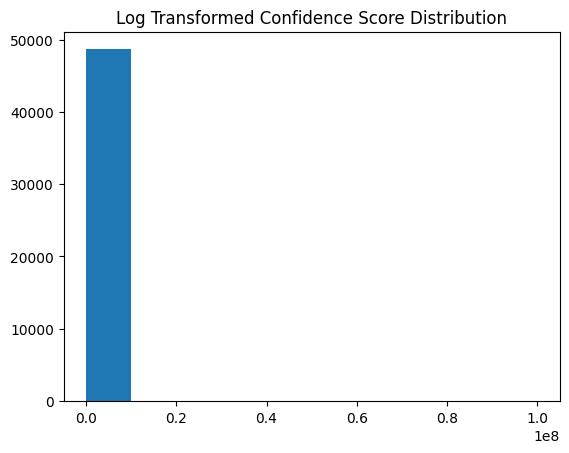

In [58]:
##CONFIDENCE SCORE DISTRIBUTION
plt.hist(merged["confidence_score"])
plt.title("Confidence Score Distribution")

##PLOT LOG TRANSFORMED CONFIDENCE SCORE DISTRIBUTION
plt.hist(merged["confidence_score"].apply(lambda x: np.log(x) if x > 0 else 0))
plt.title("Log Transformed Confidence Score Distribution")

## Create confidence score table

In [59]:
##DROP NA
conf_score_df = merged[~merged["confidence_score"].isna()]

##LOG TRANSFORM CONFIDENCE SCORES
conf_score_df["log_conf_score"] = conf_score_df["confidence_score"].apply(lambda x: np.log(x) if x > 0 else 0)

##SIGMOID TRANSFORM CONFIDENCE SCORES
conf_score_df["sigmoid_conf_score"] = conf_score_df["confidence_score"].apply(lambda x: 1 / (1 + np.exp(-x)))

##SCALE
conf_score_df["scaled_log_conf_score"] = StandardScaler().fit_transform(conf_score_df[["log_conf_score"]])


display(conf_score_df.head(5))

,Unnamed: 0,id,iteration,model,question,choices,domain,prompt_tokens,previous_answer,updated_answer,...,score,score_moving_avg,score_moving_variance,chosen_response,confidence_score,question_id,answer,log_conf_score,sigmoid_conf_score,scaled_log_conf_score
2,2,3206,2,meta-llama/Llama-3.1-8B-Instruct:cerebras,The geneticist Mary Lyon hypothesized the exis...,"['In the early female embryo, one copy of the ...",biology,517,The statement that the same chromosome in ever...,The statement that the same chromosome in ever...,...,80.0,81.666667,308.333333,False,0.147844,3206,B,-1.911595,0.536894,0.286883
3,3,3206,3,openai/gpt-oss-20b:groq,The geneticist Mary Lyon hypothesized the exis...,"['In the early female embryo, one copy of the ...",biology,517,The statement that the same chromosome in ever...,The incorrect statement is B. In a normal fema...,...,65.0,81.666667,308.333333,False,0.128609,3206,B,-2.050979,0.532108,0.216945
4,4,3206,4,Qwen/Qwen2.5-7B-Instruct:together,The geneticist Mary Lyon hypothesized the exis...,"['In the early female embryo, one copy of the ...",biology,353,The incorrect statement is B. In a normal fema...,The incorrect statement is B. In a normal fema...,...,90.0,78.333333,158.333333,False,0.208494,3206,B,-1.567846,0.551935,0.459362
5,5,3206,5,meta-llama/Llama-3.1-8B-Instruct:cerebras,The geneticist Mary Lyon hypothesized the exis...,"['In the early female embryo, one copy of the ...",biology,538,The incorrect statement is B. In a normal fema...,The statement that is NOT correct about Barr b...,...,80.0,78.333333,158.333333,False,0.191289,3206,B,-1.653970,0.547677,0.416149
6,6,3206,6,openai/gpt-oss-20b:groq,The geneticist Mary Lyon hypothesized the exis...,"['In the early female embryo, one copy of the ...",biology,434,The statement that is NOT correct about Barr b...,"Barr bodies are the condensed, inactive X chro...",...,75.0,81.666667,58.333333,False,0.472967,3206,B,-0.748730,0.616086,0.870363


## 2. Correct response by confidence score bin

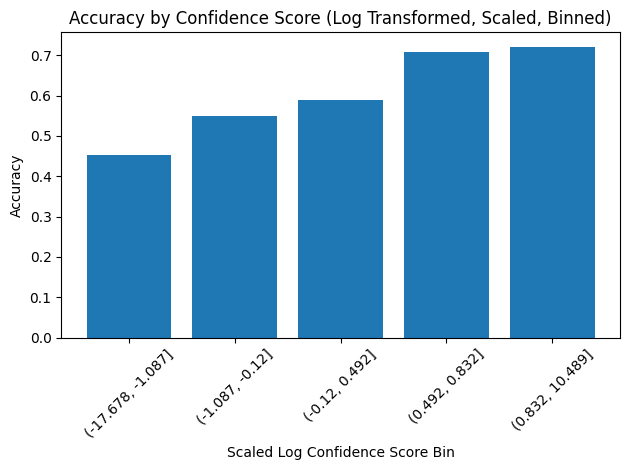

In [60]:
##PLOT ACCURACY BY CONFIDENCE SCORE BINS
conf_score_df["scaled_log_conf_score"].describe()

conf_score_df["correct"] = conf_score_df["selected_choice"] == conf_score_df["answer"]

conf_score_df["conf_score_bin"] = pd.qcut(conf_score_df["scaled_log_conf_score"], q=5)

accuracy_by_bin = conf_score_df.groupby("conf_score_bin")["correct"].mean().reset_index()

plt.bar(accuracy_by_bin["conf_score_bin"].astype(str), accuracy_by_bin["correct"])
plt.xticks(rotation=45)
plt.xlabel("Scaled Log Confidence Score Bin")
plt.ylabel("Accuracy")
plt.title("Accuracy by Confidence Score (Log Transformed, Scaled, Binned)")
plt.tight_layout()
plt.show()

## Correlation between confidence score and correct answer

In [61]:
coef, p = stats.pointbiserialr(conf_score_df["scaled_log_conf_score"], conf_score_df["correct"])
print(f"Point Biserial Correlation Coefficient: {coef:.4f}, p-value: {p:.4f}")

Point Biserial Correlation Coefficient: 0.1925, p-value: 0.0000


In [62]:
print(len(conf_score_df))

48693


### Calculate equal frequency expected callibration error

Expected Calibration Error (ECE): 0.1445
298
297
297
298
300
296
303
316
291
278
Median Max Iterations By Bin: [np.float64(11.5), np.float64(19.0), np.float64(12.0), np.float64(7.0), np.float64(8.0), np.float64(10.0), np.float64(11.0), np.float64(7.0), np.float64(4.0), np.float64(2.0)]


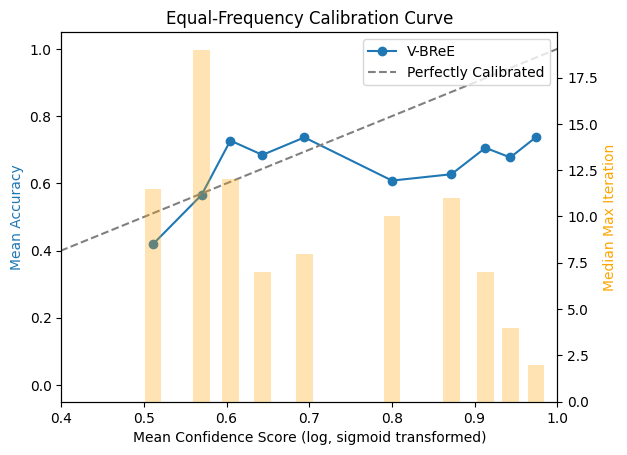

   Bin Confidence  Bin Accuracy
0        0.511141      0.419463
1        0.569770      0.565657
2        0.604548      0.727273
3        0.643341      0.684564
4        0.694109      0.736667
5        0.800086      0.608108
6        0.871934      0.627063
7        0.913105      0.705696
8        0.943133      0.676976
9        0.974223      0.737410


In [80]:
##CALCULATE EQUAL FREQUENCY EXPECTED CALIBRATION ERROR
def calculate_ece(df, n_bins=10):
    df["bin"] = pd.qcut(df["sigmoid_conf_score"], q=n_bins, labels=False)
    
    ece = 0.0
    ece_values = []
    for i in range(n_bins):
        bin_df = df[df["bin"] == i]
        if len(bin_df) > 0:
            bin_accuracy = bin_df["correct"].mean()
            bin_confidence = bin_df["sigmoid_conf_score"].mean()
            bin_ece = (len(bin_df) / len(df)) * abs(bin_accuracy - bin_confidence)
            ece += bin_ece
            ece_values.append(bin_ece)
    
    return ece

##PLOT CALIBRATION CURVE
def plot_calibration_curve(df, n_bins=10):
    df["bin"] = pd.qcut(df["sigmoid_conf_score"], q=n_bins, labels=False)

    ##ADD MAX ITERATION TO BIN DF    
    max_iter_by_question_id = df.groupby("question_id")["iteration"].max().reset_index()
    selected_conf_w_iter = pd.merge(df, max_iter_by_question_id, on="question_id", how="left")
    selected_conf_w_iter = selected_conf_w_iter.rename(columns={"iteration_y": "max_iteration", "iteration_x": "iteration"})

    bin_accuracies = []
    bin_confidences = []
    bin_median_max_iterations = []
    
    for i in range(n_bins):
        bin_df = selected_conf_w_iter[selected_conf_w_iter["bin"] == i]
        if len(bin_df) > 0:
            print(len(bin_df))
            bin_accuracy = bin_df["correct"].mean()
            bin_confidence = bin_df["sigmoid_conf_score"].mean()
            bin_accuracies.append(bin_accuracy)
            bin_confidences.append(bin_confidence)

            ##CALCULATE MEDIAN MAX ITER FOR CURRENT BIN
            median_max_iter = bin_df["max_iteration"].median()
            bin_median_max_iterations.append(median_max_iter)
    
    plt.plot(bin_confidences, bin_accuracies, marker='o')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlim(0.4, 1.0)
    plt.xlabel("Mean Confidence Score (log, sigmoid transformed)")
    plt.ylabel("Mean Accuracy", color='C0')
    plt.title("Equal-Frequency Calibration Curve")
    plt.legend(["V-BReE", "Perfectly Calibrated"], loc = "upper right")

    ##ADD SECOND AXIS TO PLOT MEDIAN MAX ITERATIONS
    ax2 = plt.gca().twinx()
    ax2.bar(bin_confidences, bin_median_max_iterations, color='orange', alpha=0.3, width=0.02)
    ax2.set_ylabel("Median Max Iteration", color='orange')

    print("Median Max Iterations By Bin:", bin_median_max_iterations)

    #plt.grid()
    plt.show()

    ##PRINT TABLE OF BIN ACCURACIES AND CONFIDENCES
    calibration_table = pd.DataFrame({"Bin Confidence": bin_confidences, "Bin Accuracy": bin_accuracies})
    print(calibration_table)

selected_conf_score_df = conf_score_df[conf_score_df["chosen_response"] == True]
ece_value = calculate_ece(selected_conf_score_df)
print(f"Expected Calibration Error (ECE): {ece_value:.4f}")

plot_calibration_curve(selected_conf_score_df)